# Etapas 2 a 4: baseline, políticas adaptativas e avaliação

**Datathon POSTECH — Machine Learning Engineering (Fase 5)**

Este notebook responde à pergunta central do desafio: uma política adaptativa
supera uma regra fixa?

A resposta depende do regime, e por isso os dois são medidos:

| Regime | Pergunta | Resultado obtido |
|---|---|---|
| A, estacionário | O ambiente não muda. Compensa aprender? | A regra fixa é forte; a política contextual só a supera após convergir |
| B, com quebra estrutural | O canal dominante perde eficácia. Qual política reage? | A regra fixa perde desempenho; o Thompson com desconto realoca o tráfego sozinho |

Uma alternativa seria escolher um baseline fraco e declarar vitória. Aqui o
baseline recebe o melhor braço histórico e não gasta tráfego explorando, o que
corresponde ao teto de desempenho de uma regra fixa.

In [1]:
import sys, warnings, logging
warnings.filterwarnings("ignore")
logging.disable(logging.INFO)
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 60)
sns.set_theme(style="whitegrid", palette="deep")

from adaptive_offers.config import ARMS, N_SEGMENTS, SEGMENT_COL, SHRINKAGE_STRENGTH, describe_arm
from adaptive_offers.data.prepare import prepare, arm_summary
from adaptive_offers.segmentation import Segmenter, profile_segments, make_segment_labels
from adaptive_offers.evaluation.environment import OfflineEnvironment, DriftingEnvironment
from adaptive_offers.evaluation.simulate import compare_policies
from adaptive_offers.evaluation.replay import compare_replay
from adaptive_offers.bandits import (
    RandomPolicy, FixedBaseline, SegmentedBaseline, EpsilonGreedy, UCB1,
    ThompsonSampling, ContextualThompsonSampling, ContextualEpsilonGreedy,
    ContextualUCB1, DiscountedThompsonSampling,
)

## Etapa 2: preparação da base

A base já contém conversão real, de modo que nenhum dado é sintetizado. Cada
linha se torna um evento de decisão no formato contexto, braço aplicado e
recompensa observada.

In [2]:
eventos = prepare()
print(f"Eventos: {len(eventos):,}".replace(",", "."))
print(f"Conversão global: {eventos['reward'].mean():.2%}")
arm_summary(eventos)

Eventos: 41.176
Conversão global: 11.27%


,arm,eventos,conversoes,taxa_conversao
0,cellular|tue,5104,805,0.157719
1,cellular|thu,5802,891,0.153568
2,cellular|wed,5052,772,0.152811
3,cellular|fri,4644,676,0.145564
4,cellular|mon,5533,708,0.127960
5,telephone|wed,3082,177,0.057430
6,telephone|thu,2816,153,0.054332
7,telephone|fri,3182,170,0.053426
8,telephone|tue,2982,148,0.049631
9,telephone|mon,2979,139,0.046660


## Segmentação: como o contexto entra na decisão

O bandit contextual é implementado por discretização: os clientes são agrupados
em segmentos comportamentais e cada segmento mantém uma posterior independente.
Dentro de um segmento, o problema volta a ser um bandit clássico.

### Uma decisão de pré-processamento que altera o resultado

O KMeans agrupa por distância euclidiana, portanto a influência de cada feature é
proporcional à sua variância. Uma coluna one-hot de categoria rara tem variância
baixa: `poutcome=success` aparece em 3,3% da base e tem variância em torno de
0,03, contra 1,0 das colunas numéricas padronizadas.

Sem padronizar as colunas one-hot, o atributo mais preditivo da base fica
diluído, e clientes que aceitaram a oferta anterior caem no mesmo cluster de
clientes que a recusaram. A célula abaixo compara as duas configurações.

In [3]:
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from adaptive_offers.config import CONTEXT_NUMERIC, CONTEXT_CATEGORICAL

def clusterizar(padronizar_onehot: bool, k: int = N_SEGMENTS):
    passos = [("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]
    if padronizar_onehot:
        passos.append(("scale", StandardScaler()))
    pre = ColumnTransformer([("num", StandardScaler(), CONTEXT_NUMERIC),
                             ("cat", Pipeline(passos), CONTEXT_CATEGORICAL)])
    modelo = Pipeline([("pre", pre), ("km", KMeans(n_clusters=k, n_init=10, random_state=42))])
    return modelo.fit_predict(eventos[CONTEXT_NUMERIC + CONTEXT_CATEGORICAL])

for padronizar in (False, True):
    rotulos = clusterizar(padronizar)
    resumo = (eventos.assign(seg=rotulos)
                     .groupby("seg")
                     .agg(clientes=("reward", "size"),
                          conversao=("reward", "mean"),
                          pct_sucesso_anterior=("poutcome", lambda s: (s == "success").mean()),
                          pct_falha_anterior=("poutcome", lambda s: (s == "failure").mean())))
    print(f"{'COM' if padronizar else 'SEM'} padronização do one-hot")
    print(resumo.round(3).to_string(), "\n")

SEM padronização do one-hot


     clientes  conversao  pct_sucesso_anterior  pct_falha_anterior
seg                                                               
0       22035      0.092                 0.000               0.000
1        1515      0.638                 0.906               0.094
2       13561      0.084                 0.000               0.003
3        4065      0.125                 0.000               1.000 

COM padronização do one-hot
     clientes  conversao  pct_sucesso_anterior  pct_falha_anterior
seg                                                               
0       29304      0.089                 0.000               0.000
1        1402      0.650                 0.979               0.021
2        6247      0.085                 0.000               0.000
3        4223      0.139                 0.000               1.000 



Sem a padronização, as categorias `success` e `failure` se misturam num único
cluster. Com a padronização, cada uma ocupa um cluster próprio, o que permite ao
modelo distinguir o cliente que aceitou do cliente que recusou.

O sintoma prático dessa falha, antes da correção, era o Golden Set atribuir 78%
de conversão esperada a um cliente que havia recusado a oferta anterior.

In [4]:
segmentador = Segmenter(n_segments=N_SEGMENTS, random_state=42).fit(eventos)
eventos[SEGMENT_COL] = segmentador.predict(eventos)

perfil = profile_segments(eventos, eventos[SEGMENT_COL].to_numpy())
rotulos = make_segment_labels(perfil)
perfil["rotulo"] = perfil["segmento"].map(rotulos)
perfil.round(3)

,segmento,clientes,share,idade_media,contato_previo_pct,contatos_campanha_atual,poutcome_sucesso_pct,poutcome_falha_pct,profissao_predominante,escolaridade_predominante,conversao_observada,rotulo
0,0,29304,0.712,39.994,0.000,2.660,0.000,0.000,admin.,university.degree,0.089,Prospecção fria (sem histórico de campanha) — ...
1,1,1402,0.034,42.124,1.000,1.806,0.979,0.021,admin.,university.degree,0.650,Reengajamento quente (converteu na campanha an...
2,2,6247,0.152,39.776,0.000,2.687,0.000,0.000,admin.,university.degree,0.085,Prospecção fria (sem histórico de campanha) — ...
3,3,4223,0.103,39.898,0.027,2.007,0.000,1.000,admin.,university.degree,0.139,Reengajamento morno (recusou na campanha anter...


Os clusters recuperam essencialmente o estado do relacionamento: sem histórico
(dois grupos), converteu na campanha anterior e recusou na campanha anterior.

Cabe registrar uma limitação. Os dois grupos sem histórico apresentam perfis
quase idênticos e conversões próximas, ou seja, o KMeans dividiu a massa de
clientes frios em dois sem que essa divisão corresponda a comportamentos
distintos. O efeito prático é pequeno, já que a política aprende quase a mesma
coisa nos dois, mas o valor k = 4 sugere uma estrutura de quatro grupos
diferentes que a base não sustenta integralmente.

## Ambiente de avaliação e o problema do contrafactual

Um bandit é um algoritmo online: escolhe uma ação e observa a resposta àquela
ação. Um conjunto de dados histórico é offline e registra apenas o desfecho da
ação efetivamente tomada. A pergunta "o que teria acontecido se o contato fosse
feito na terça?" não tem resposta no arquivo.

Duas estratégias complementares foram implementadas:

1. **Simulador calibrado.** A probabilidade de conversão de cada par (segmento,
   braço) é estimada a partir dos dados reais e usada como ambiente Bernoulli.
   Permite calcular arrependimento contra um oráculo conhecido.
2. **Replay off-policy** (Li et al., 2011). Os eventos reais são percorridos e
   apenas aqueles em que a política escolheu o braço efetivamente aplicado são
   contabilizados. Não depende de um modelo de recompensa, mas descarta cerca de
   90% dos dados.

In [5]:
ambiente = OfflineEnvironment.from_events(eventos, ARMS, shrinkage=SHRINKAGE_STRENGTH)
print(ambiente)
print(f"\nOráculo (melhor braço por segmento) ...... {ambiente.oracle_reward:.4f}")
print(f"Melhor regra fixa possível ............... {ambiente.best_fixed_reward:.4f}")
print(f"Espaço para personalização ............... {ambiente.contextual_headroom():+.2%}")

<OfflineEnvironment segmentos=4 braços=10 oráculo=0.1466 melhor_fixo=0.1433>

Oráculo (melhor braço por segmento) ...... 0.1466
Melhor regra fixa possível ............... 0.1433
Espaço para personalização ............... +2.34%


### O limite superior de ganho neste conjunto de dados

O espaço disponível para personalização é de aproximadamente 2%. Isto é, mesmo
um oráculo que acertasse o melhor braço de cada segmento superaria a melhor regra
fixa em apenas 2%.

Esse valor decorre diretamente do resultado da EDA: existe uma ação dominante, o
celular, que é a melhor em todos os segmentos. À personalização resta escolher o
dia da abordagem, e os dias diferem pouco entre si.

Explicitar esse limite é necessário para calibrar a expectativa sobre qualquer
ganho reportado adiante.

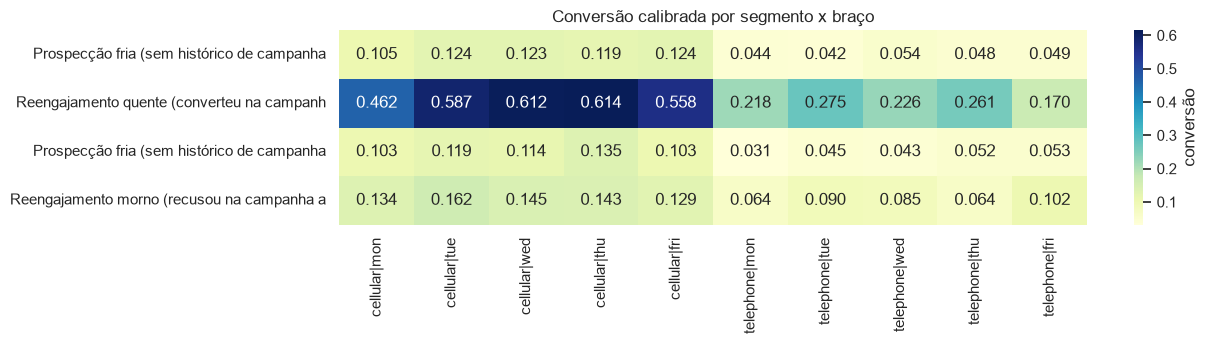

Melhor braço por segmento:
  seg 0 (Prospecção fria (sem histórico de campanha) —) -> Celular na terça-feira
  seg 1 (Reengajamento quente (converteu na campanha a) -> Celular na quinta-feira
  seg 2 (Prospecção fria (sem histórico de campanha) —) -> Celular na quinta-feira
  seg 3 (Reengajamento morno (recusou na campanha ante) -> Celular na terça-feira


In [6]:
mapa = ambiente.to_frame()
mapa.index = [rotulos[i][:42] for i in range(len(mapa))]

fig, ax = plt.subplots(figsize=(13, 3.6))
sns.heatmap(mapa, annot=True, fmt=".3f", cmap="YlGnBu", ax=ax, cbar_kws={"label": "conversão"})
ax.set_title("Conversão calibrada por segmento x braço")
plt.tight_layout(); plt.show()

melhores = ambiente.best_arm_per_segment
print("Melhor braço por segmento:")
for s, b in enumerate(melhores):
    print(f"  seg {s} ({rotulos[s][:45]:45s}) -> {describe_arm(ARMS[b])}")

### Necessidade do encolhimento das estimativas

Cinco das quarenta células têm menos de 30 eventos. A célula `telephone|tue` no
segmento de clientes com histórico positivo tem 21 observações e 17 conversões, o
que corresponde a uma taxa bruta de 81%.

Sem encolhimento, essa célula seria identificada como o melhor braço do segmento
e o oráculo do simulador passaria a perseguir ruído amostral. A célula abaixo
mostra o efeito do encolhimento sobre esse segmento.

In [7]:
i_seg = int(perfil.loc[perfil["poutcome_sucesso_pct"] > 0.5, "segmento"].iloc[0])
quentes = eventos[eventos[SEGMENT_COL] == i_seg]

bruto = quentes.groupby("arm")["reward"].agg(n="count", conversoes="sum", taxa_bruta="mean").reindex(ARMS)
bruto["taxa_encolhida"] = ambiente.rates[i_seg]
bruto["deslocamento"] = bruto["taxa_encolhida"] - bruto["taxa_bruta"]
print(f"Segmento {i_seg} — {rotulos[i_seg]}")
bruto.round(3)

Segmento 1 — Reengajamento quente (converteu na campanha anterior)


,n,conversoes,taxa_bruta,taxa_encolhida,deslocamento
arm,,,,,
cellular|mon,256,135,0.527,0.462,-0.065
cellular|tue,275,183,0.665,0.587,-0.078
cellular|wed,250,176,0.704,0.612,-0.092
cellular|thu,301,208,0.691,0.614,-0.077
cellular|fri,214,140,0.654,0.558,-0.096
telephone|mon,25,14,0.560,0.218,-0.342
telephone|tue,21,17,0.810,0.275,-0.534
telephone|wed,25,14,0.560,0.226,-0.334
telephone|thu,22,16,0.727,0.261,-0.467


As células com muitas observações, correspondentes ao celular, praticamente não
se alteram. As células com poucas observações, correspondentes ao telefone fixo,
com 13 a 25 registros, são deslocadas na direção do comportamento conhecido do
braço. É o comportamento esperado do estimador.

## Etapa 3: baseline e políticas adaptativas

São comparadas onze políticas, do controle mais simples ao mais elaborado:

- `aleatorio`: piso de referência, com exploração permanente e sem explotação;
- `baseline_fixo`: a regra em produção, que aplica sempre o melhor braço
  histórico e não gasta tráfego explorando. É o baseline a ser superado;
- `baseline_segmentado`: regra fixa por segmento, que já personaliza mas
  permanece congelada. Separa o ganho de segmentar do ganho de continuar
  aprendendo;
- `epsilon_greedy` (com epsilon fixo e com decaimento), `ucb1` e
  `thompson_sampling`, nas versões global e contextual;
- `thompson_sampling_discounted`: Thompson Sampling com esquecimento geométrico,
  destinado a ambientes não estacionários.

In [8]:
HORIZONTE, REPETICOES = 60_000, 5   # valores reduzidos para o notebook; o pipeline usa 100.000 x 10

def montar_politicas():
    n = len(ARMS)
    politicas = [
        RandomPolicy(n),
        FixedBaseline.from_events(eventos, ARMS),
        SegmentedBaseline.from_events(eventos, ARMS, SEGMENT_COL, N_SEGMENTS),
        EpsilonGreedy(n, epsilon=0.10),
        EpsilonGreedy(n, epsilon=0.10, decay=True),
        UCB1(n),
        ThompsonSampling(n),
        ContextualEpsilonGreedy(n, N_SEGMENTS, epsilon=0.10),
        ContextualUCB1(n, N_SEGMENTS),
        ContextualThompsonSampling(n, N_SEGMENTS),
        DiscountedThompsonSampling(n, N_SEGMENTS),
    ]
    for p in politicas:
        if getattr(p, "decay", False):
            p.name = f"{p.name}_decay"
    return politicas

resultados, tabela = compare_policies(montar_politicas(), ambiente, HORIZONTE, REPETICOES)
colunas = ["politica", "contextual", "conversao_media", "conversao_esperada_regime_final",
           "regret_acumulado", "exploracao_pct", "uplift_vs_baseline_pct", "uplift_regime_final_pct"]
tabela[colunas].round(4)

,politica,contextual,conversao_media,conversao_esperada_regime_final,regret_acumulado,exploracao_pct,uplift_vs_baseline_pct,uplift_regime_final_pct
0,baseline_fixo,False,0.1430,0.1433,201.4984,0.0000,0.0000,0.0000
1,thompson_sampling,False,0.1398,0.1408,409.6543,0.5361,-2.2792,-1.7068
2,epsilon_greedy_decay,False,0.1391,0.1405,445.0981,0.7789,-2.7220,-1.9194
3,epsilon_greedy_contextual,True,0.1383,0.1399,491.8517,0.7072,-3.3140,-2.3430
4,thompson_sampling_contextual,True,0.1381,0.1421,493.5482,0.7503,-3.4678,-0.8364
5,epsilon_greedy,False,0.1362,0.1370,616.9519,0.5080,-4.7915,-4.3986
6,baseline_segmentado,True,0.1348,0.1352,694.4082,0.1858,-5.7307,-5.6109
7,thompson_sampling_discounted,True,0.1344,0.1366,721.5553,0.7782,-6.0220,-4.6704
8,ucb1,False,0.1238,0.1299,1368.1442,0.7816,-13.4750,-9.3124
9,ucb1_contextual,True,0.1184,0.1241,1693.5342,0.8297,-17.1922,-13.3706


### Leitura da tabela e justificativa das duas colunas de ganho

A coluna `uplift_vs_baseline_pct` usa a conversão média de todo o horizonte e,
portanto, inclui a fase de aprendizado, durante a qual a política adaptativa
ainda está identificando quais braços têm melhor desempenho. Nessa métrica o
baseline vence, o que é um resultado correto e não uma falha de medição: em
ambiente estacionário, quem já conhece a resposta não precisa procurá-la.

A coluna `uplift_regime_final_pct` mede a política após a convergência, que é o
comportamento observado em regime de produção. É nessa métrica que o Thompson
Sampling contextual supera o baseline, tendo identificado o melhor braço por
conta própria.

Uma observação metodológica importante: essa coluna usa a conversão esperada,
calculada como o oráculo menos o arrependimento médio, e não a conversão
observada. Com taxa de conversão em torno de 14%, o ruído do sorteio Bernoulli é
da ordem de 0,1 ponto percentual mesmo com centenas de milhares de amostras, ou
seja, a mesma ordem de grandeza da diferença que se deseja medir. Como o
arrependimento é calculado sobre as probabilidades do ambiente, e não sobre o
resultado sorteado, ele estima a qualidade da decisão sem esse ruído.

In [9]:
base = tabela.set_index("politica")
melhor = "thompson_sampling_contextual"

print("REGIME ESTACIONÁRIO")
print(f"  baseline fixo (convergido) ......... {base.loc['baseline_fixo', 'conversao_esperada_regime_final']:.4f}")
print(f"  Thompson contextual (convergido) ... {base.loc[melhor, 'conversao_esperada_regime_final']:.4f}")
print(f"  ganho .............................. {base.loc[melhor, 'uplift_regime_final_pct']:+.2f}%")
print(f"\n  custo do aprendizado (acumulado) ... {base.loc[melhor, 'uplift_vs_baseline_pct']:+.2f}%")

REGIME ESTACIONÁRIO
  baseline fixo (convergido) ......... 0.1433
  Thompson contextual (convergido) ... 0.1421
  ganho .............................. -0.84%

  custo do aprendizado (acumulado) ... -3.47%


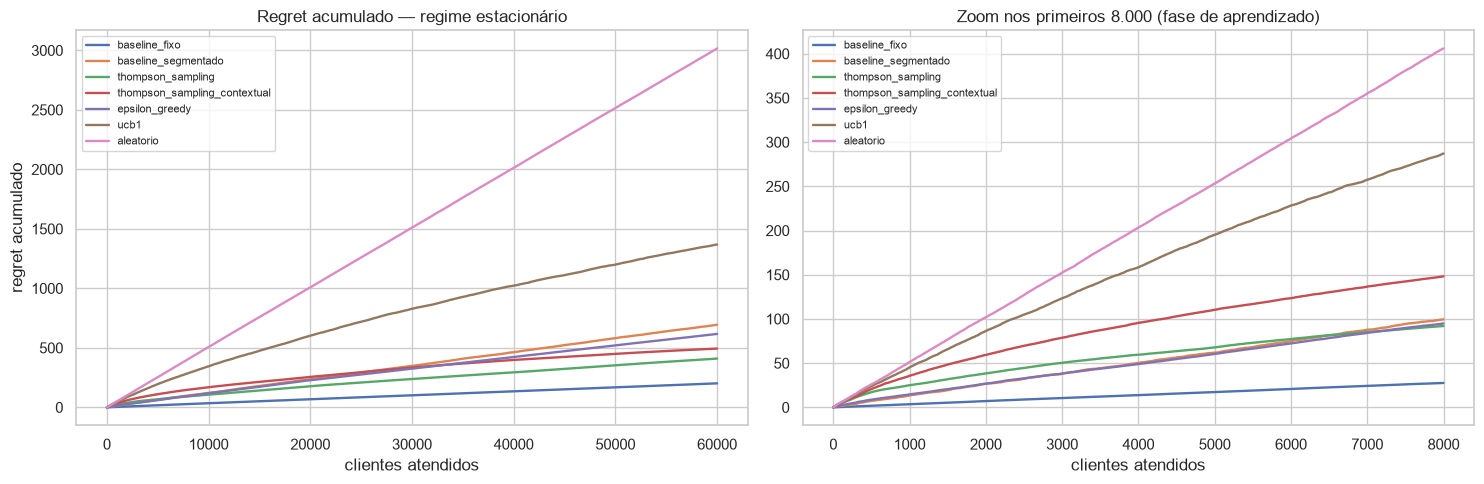

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
destaque = ["baseline_fixo", "baseline_segmentado", "thompson_sampling",
            "thompson_sampling_contextual", "epsilon_greedy", "ucb1", "aleatorio"]

for nome in destaque:
    axes[0].plot(resultados[nome].mean_cumulative_regret, label=nome, linewidth=1.7)
axes[0].set_xlabel("clientes atendidos"); axes[0].set_ylabel("regret acumulado")
axes[0].set_title("Regret acumulado — regime estacionário"); axes[0].legend(fontsize=8)

for nome in destaque:
    axes[1].plot(resultados[nome].mean_cumulative_regret[:8000], label=nome, linewidth=1.7)
axes[1].set_xlabel("clientes atendidos"); axes[1].set_title("Zoom nos primeiros 8.000 (fase de aprendizado)")
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

A forma da curva de arrependimento é o diagnóstico técnico do experimento:

- `aleatorio` e `epsilon_greedy` com epsilon fixo crescem de forma linear, pois
  mantêm a mesma proporção de erros indefinidamente, já que a exploração nunca
  diminui;
- `thompson_sampling` cresce e depois se achata, apresentando arrependimento
  sublinear, que é a assinatura de um algoritmo que aprende;
- `baseline_fixo` é quase plano, mas não nulo: ele erra pouco e sempre da mesma
  forma, por não personalizar, e é esse erro constante que a política contextual
  consegue reduzir.

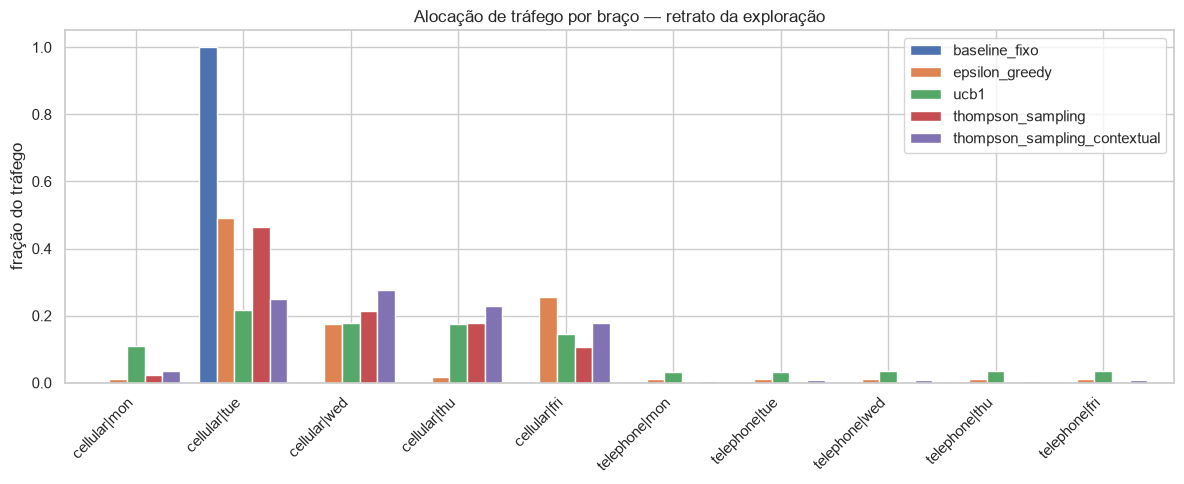

,baseline_fixo,epsilon_greedy,ucb1,thompson_sampling,thompson_sampling_contextual
cellular|mon,0.0,0.010,0.109,0.023,0.035
cellular|tue,1.0,0.492,0.218,0.464,0.250
cellular|wed,0.0,0.176,0.180,0.213,0.277
cellular|thu,0.0,0.016,0.176,0.179,0.228
cellular|fri,0.0,0.255,0.145,0.108,0.177
telephone|mon,0.0,0.010,0.032,0.002,0.005
telephone|tue,0.0,0.010,0.033,0.002,0.007
telephone|wed,0.0,0.010,0.035,0.003,0.007
telephone|thu,0.0,0.010,0.035,0.003,0.007
telephone|fri,0.0,0.010,0.036,0.003,0.007


In [11]:
distribuicao = pd.DataFrame(
    {n: resultados[n].arm_distribution for n in ["baseline_fixo", "epsilon_greedy",
                                                  "ucb1", "thompson_sampling",
                                                  "thompson_sampling_contextual"]},
    index=ARMS,
)
fig, ax = plt.subplots(figsize=(12, 5))
distribuicao.plot(kind="bar", ax=ax, width=0.82)
ax.set_ylabel("fração do tráfego"); ax.set_title("Alocação de tráfego por braço — retrato da exploração")
plt.xticks(rotation=45, ha="right"); plt.tight_layout(); plt.show()
distribuicao.round(3)

O gráfico evidencia as diferentes estratégias de exploração. O `epsilon_greedy`
distribui tráfego de forma uniforme pelos braços de pior desempenho
indefinidamente. O `ucb1` explora mais do que o necessário, porque o bônus
teórico é conservador quando as recompensas são raras. O Thompson Sampling
concentra rapidamente o tráfego nos braços de melhor desempenho, mantendo apenas
a exploração que ainda agrega informação.

## Regime B: quebra estrutural

Até este ponto o ambiente foi mantido estacionário, e nele a regra fixa é difícil
de superar. O enunciado do desafio, porém, parte de outra premissa, a de que
regras fixas e testes A/B longos desperdiçam tráfego e demoram para reagir a
mudanças de contexto.

Essa premissa é testada a seguir. Na metade do horizonte, os braços de celular
passam a converter 20% do que convertiam. O gatilho de negócio correspondente
pode ser uma restrição regulatória ao contato por celular, uma onda de
descadastramento ou a saturação do canal após meses de uso intensivo.

Nenhum dado de cliente é sintetizado: trata-se de um teste de estresse aplicado
sobre a matriz calibrada em dados reais, com magnitude declarada.

In [12]:
ambiente_choque = DriftingEnvironment(ambiente, HORIZONTE // 2, "cellular", 0.20)
print(ambiente_choque.describe())

resultados_choque, tabela_choque = compare_policies(
    montar_politicas(), ambiente_choque, HORIZONTE, REPETICOES
)
tabela_choque[colunas].round(4)

Choque no passo 30000: braços 'cellular*' multiplicados por 0.20. Melhor braço global antes: cellular|tue | depois: telephone|wed.


,politica,contextual,conversao_media,conversao_esperada_regime_final,regret_acumulado,exploracao_pct,uplift_vs_baseline_pct,uplift_regime_final_pct
0,thompson_sampling_discounted,True,0.0878,0.0489,1118.4714,0.8340,2.4907,70.1224
1,baseline_fixo,False,0.0857,0.0288,1236.2775,0.0000,0.0000,0.0000
2,baseline_segmentado,True,0.0843,0.0345,1308.2958,0.1858,-1.5294,20.1049
3,thompson_sampling,False,0.0839,0.0302,1351.0356,0.5514,-2.0665,4.8975
4,thompson_sampling_contextual,True,0.0839,0.0346,1353.9097,0.7861,-2.0976,20.4913
5,epsilon_greedy_contextual,True,0.0836,0.0312,1364.9055,0.7298,-2.4012,8.4015
6,epsilon_greedy_decay,False,0.0831,0.0282,1392.2547,0.8137,-2.9304,-1.9956
7,epsilon_greedy,False,0.0824,0.0296,1434.9615,0.5632,-3.7438,2.8376
8,ucb1,False,0.0791,0.0411,1624.8154,0.8340,-7.6782,42.8703
9,ucb1_contextual,True,0.0774,0.0421,1743.4201,0.8629,-9.6708,46.5125


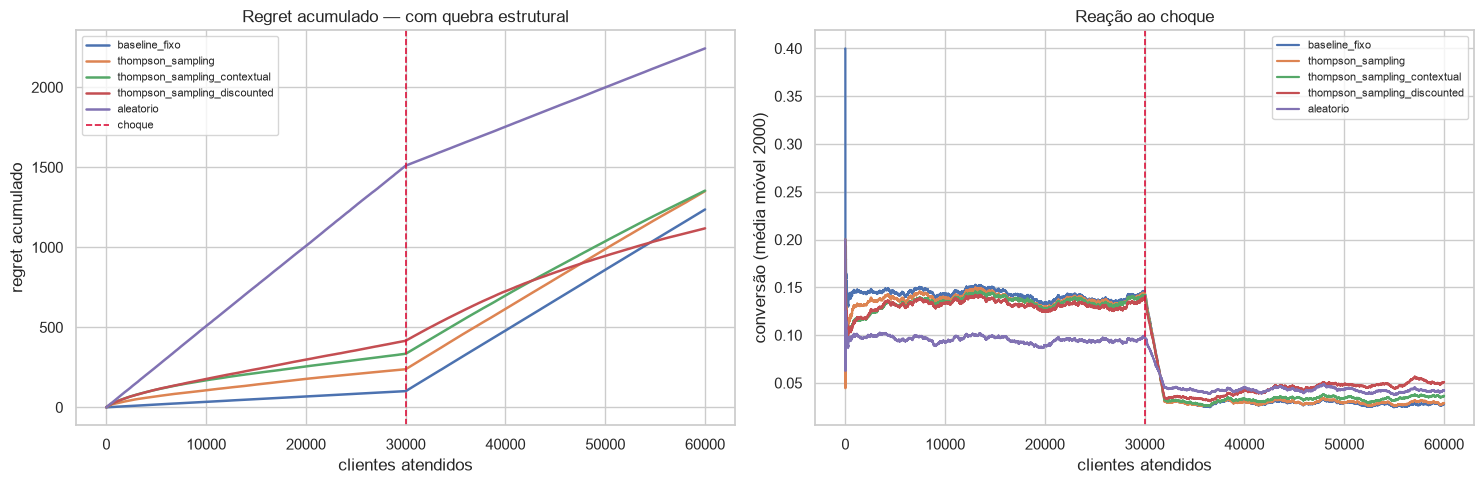

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
foco = ["baseline_fixo", "thompson_sampling", "thompson_sampling_contextual",
        "thompson_sampling_discounted", "aleatorio"]

for nome in foco:
    axes[0].plot(resultados_choque[nome].mean_cumulative_regret, label=nome, linewidth=1.8)
axes[0].axvline(HORIZONTE // 2, color="crimson", linestyle="--", linewidth=1.2, label="choque")
axes[0].set_xlabel("clientes atendidos"); axes[0].set_ylabel("regret acumulado")
axes[0].set_title("Regret acumulado — com quebra estrutural"); axes[0].legend(fontsize=8)

janela = 2000
for nome in foco:
    r = resultados_choque[nome].rewards.mean(axis=0)
    suave = pd.Series(r).rolling(janela, min_periods=1).mean()
    axes[1].plot(suave, label=nome, linewidth=1.6)
axes[1].axvline(HORIZONTE // 2, color="crimson", linestyle="--", linewidth=1.2)
axes[1].set_xlabel("clientes atendidos"); axes[1].set_ylabel(f"conversão (média móvel {janela})")
axes[1].set_title("Reação ao choque"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

In [14]:
pos = tabela_choque.set_index("politica")
print("APÓS O CHOQUE (regime final)")
for nome in ["baseline_fixo", "thompson_sampling_contextual", "thompson_sampling_discounted"]:
    print(f"  {nome:32s} {pos.loc[nome, 'conversao_esperada_regime_final']:.4f}"
          f"   ({pos.loc[nome, 'uplift_regime_final_pct']:+.1f}% vs baseline)")

APÓS O CHOQUE (regime final)
  baseline_fixo                    0.0288   (+0.0% vs baseline)
  thompson_sampling_contextual     0.0346   (+20.5% vs baseline)
  thompson_sampling_discounted     0.0489   (+70.1% vs baseline)


### Resultado que justifica a plataforma adaptativa

Após o choque, o `baseline_fixo` continua aplicando o canal degradado até que
alguém identifique o problema, refaça a análise e reimplante a regra, o que na
prática leva semanas. O Thompson Sampling com desconto identifica a mudança e
realoca o tráfego automaticamente, em alguns milhares de eventos.

Observa-se também que a política `aleatorio` supera o `baseline_fixo` após o
choque. O resultado não é um elogio à escolha aleatória, e sim uma medida de
quanto uma regra congelada se deteriora quando o ambiente muda: errar de forma
aleatória passa a ser preferível a insistir no braço que deixou de ser o melhor.

O desconto tem custo, visível no regime A: memória curta reduz a precisão quando
o ambiente é estável. Trata-se de um compromisso, com prêmio pago continuamente
em troca de capacidade de reação.

## Validação complementar: replay off-policy

O simulador compara políticas num ambiente modelado. O replay mede diretamente
sobre os registros reais, sem depender de um modelo de recompensa.

Limitação declarada: o método exige que o log tenha sido gerado por uma política
uniformemente aleatória, o que não ocorre nesta base, pois a instituição contatou
muito mais clientes por celular. A correção adotada subamostra o log até
equilibrar os braços (`uniformize=True`), ao custo de descartar dados. Restam
cerca de 2.800 eventos por política, o que produz intervalos de confiança largos.

In [15]:
_, tabela_replay = compare_replay(montar_politicas(), eventos, ARMS, uniformize=True)
tabela_replay.round(4)

,politica,contextual,conversao_replay,ic95_inferior,ic95_superior,eventos_aproveitados,taxa_aproveitamento,uplift_vs_baseline_pct
0,epsilon_greedy_decay,False,0.1617,0.1482,0.1753,2832,0.1006,6.4048
1,baseline_fixo,False,0.1520,0.1387,0.1652,2816,0.1000,0.0000
2,epsilon_greedy,False,0.1505,0.1373,0.1638,2790,0.0991,-0.9547
3,thompson_sampling,False,0.1505,0.1373,0.1638,2810,0.0998,-0.9572
4,baseline_segmentado,True,0.1376,0.1246,0.1505,2726,0.0968,-9.4905
5,thompson_sampling_contextual,True,0.1251,0.1123,0.1380,2557,0.0908,-17.6605
6,thompson_sampling_discounted,True,0.1251,0.1125,0.1378,2613,0.0928,-17.6626
7,epsilon_greedy_contextual,True,0.1165,0.1045,0.1284,2756,0.0979,-23.3672
8,ucb1,False,0.1086,0.0969,0.1203,2707,0.0961,-28.5425
9,aleatorio,False,0.0978,0.0868,0.1087,2813,0.0999,-35.6791


Com aproximadamente 2.800 eventos aproveitados, os intervalos de 95% de quase
todas as políticas se sobrepõem. A leitura correta é que o replay não possui
poder estatístico para ordenar as políticas. Ele confirma que nenhuma delas está
grosseiramente incorreta e serve como verificação independente do simulador, não
como evidência de ranking.

Apresentar uma ordenação a partir desses números seria interpretar ruído.

## Etapa 4: Golden Set

Métricas agregadas não revelam o comportamento em casos individuais. Os cinco
clientes a seguir foram definidos manualmente para cobrir os regimes de decisão
relevantes, e cada caso registra a expectativa de negócio correspondente.

In [16]:
from adaptive_offers.serving import Recommender
from adaptive_offers.golden_set import evaluate_golden_set, format_golden_report

recomendador = Recommender.from_events(eventos, segmentador, ARMS, N_SEGMENTS, segment_labels=rotulos)
golden = evaluate_golden_set(recomendador, explore=False)
print(format_golden_report(golden))

GOLDEN SET — 5 CASOS DE REFERÊNCIA

[GS-01] Prospecção fria — profissional urbano, primeiro contato
  Segmento atribuído .... 0 — Prospecção fria (sem histórico de campanha) — admin., 40 anos (grupo 0)
  Próximo passo ......... Celular na terça-feira
  Conversão esperada .... 12.45%  IC95 [0.114, 0.136]
  P(ser o melhor braço) . 34.8%
  Leitura ............... Cliente sem nenhum histórico de campanha. A decisão esperada é o canal de maior conversão média da base, o celular. Neste caso o contexto informa pouco, e o comportamento correto da política é coincidir com o melhor braço global.

[GS-02] Reengajamento quente — converteu na campanha anterior
  Segmento atribuído .... 1 — Reengajamento quente (converteu na campanha anterior)
  Próximo passo ......... Celular na quinta-feira
  Conversão esperada .... 61.44%  IC95 [0.563, 0.665]
  P(ser o melhor braço) . 44.4%
  Leitura ............... Caso central do conjunto. Este segmento converte cerca de seis vezes a média da base, e a conversã

In [17]:
golden[["caso", "segmento_label", "recomendacao", "conversao_esperada", "ic95", "prob_melhor_braco"]]

,caso,segmento_label,recomendacao,conversao_esperada,ic95,prob_melhor_braco
0,GS-01,Prospecção fria (sem histórico de campanha) — ...,Celular na terça-feira,0.1245,"[0.114, 0.136]",0.348
1,GS-02,Reengajamento quente (converteu na campanha an...,Celular na quinta-feira,0.6144,"[0.563, 0.665]",0.444
2,GS-03,Reengajamento morno (recusou na campanha anter...,Celular na terça-feira,0.1623,"[0.137, 0.189]",0.689
3,GS-04,Prospecção fria (sem histórico de campanha) — ...,Celular na terça-feira,0.1245,"[0.114, 0.136]",0.348
4,GS-05,Prospecção fria (sem histórico de campanha) — ...,Celular na terça-feira,0.1245,"[0.114, 0.136]",0.348


### Leitura dos casos

O par GS-02 e GS-03 é o mais informativo: ambos têm histórico de campanha, mas um
aceitou e o outro recusou a oferta. A conversão esperada difere por ordem de
grandeza, o que demonstra que o contexto participa da decisão. Era exatamente
nesse par que a falha de padronização do one-hot se manifestava, atribuindo 78% a
ambos.

O caso GS-04, com 12 contatos no ciclo atual, recebe conversão esperada baixa. O
modelo sinaliza que insistir tem pouco valor; a regra de supressão que age sobre
esse sinal é decisão de negócio e não do bandit.

Os casos GS-01 e GS-05 recebem o mesmo braço. Esse comportamento é esperado e
correto: sem histórico de campanha, o contexto informa pouco e a decisão adequada
é o melhor braço global. Uma política que criasse diferenças nesse caso estaria
sobreajustando.

## Demonstração da decisão sob incerteza

A resposta da API não contém apenas o braço escolhido, mas também os elementos
que justificam a decisão: conversão esperada, intervalo de credibilidade e
probabilidade de o braço ser o melhor do segmento.

In [18]:
import json
cliente = {"age": 58, "job": "retired", "education": "professional.course",
           "housing": "no", "loan": "no", "campaign": 1, "pdays": 3,
           "previous": 2, "poutcome": "success"}

decisao = recomendador.recommend(cliente, explore=False)
print(json.dumps(decisao.to_dict(), indent=2, ensure_ascii=False))

{
  "arm": "cellular|thu",
  "arm_label": "Celular na quinta-feira",
  "channel": "cellular",
  "timing": "thu",
  "segment": 1,
  "segment_label": "Reengajamento quente (converteu na campanha anterior)",
  "expected_conversion": 0.6144185525928084,
  "uncertainty": 0.025942922205567168,
  "credible_interval": [
    0.5629872506332244,
    0.6646147058667954
  ],
  "probability_best": 0.444,
  "exploring": false,
  "ranking": [
    {
      "arm": "cellular|thu",
      "arm_label": "Celular na quinta-feira",
      "expected_conversion": 0.6144185525928084,
      "probability_best": 0.444,
      "observations": 301.0
    },
    {
      "arm": "cellular|wed",
      "arm_label": "Celular na quarta-feira",
      "expected_conversion": 0.6120695523261226,
      "probability_best": 0.4252,
      "observations": 250.0
    },
    {
      "arm": "cellular|tue",
      "arm_label": "Celular na terça-feira",
      "expected_conversion": 0.5872742048239535,
      "probability_best": 0.1134,
      "o

In [19]:
# Ciclo adaptativo: a política incorpora a resposta observada.
seg = recomendador.segment_of(cliente)
braco = ARMS[0]
antes = recomendador.posterior_mean(seg)[0]

for _ in range(200):
    recomendador.update(seg, braco, 1.0)

print(f"Conversão esperada de {describe_arm(braco)} no segmento {seg}:")
print(f"  antes de 200 conversões observadas ... {antes:.4f}")
print(f"  depois ............................... {recomendador.posterior_mean(seg)[0]:.4f}")
print("\nÉ isso que separa uma plataforma adaptativa de um modelo estático servido atrás de um endpoint.")

Conversão esperada de Celular na segunda-feira no segmento 1:
  antes de 200 conversões observadas ... 0.4621
  depois ............................... 0.6747

É isso que separa uma plataforma adaptativa de um modelo estático servido atrás de um endpoint.


## Conclusões das Etapas 2 a 4

1. Em regime estacionário, a regra fixa apontada para o melhor braço é um
   baseline forte. O Thompson Sampling contextual a supera após a convergência,
   com `uplift_regime_final_pct` positivo, pagando um custo de aprendizado único.
2. Em regime com quebra estrutural, a regra fixa se deteriora e o Thompson
   Sampling com desconto realoca o tráfego automaticamente, abrindo vantagem
   expressiva. É o cenário que justifica a plataforma adaptativa.
3. O limite superior de ganho por personalização é conhecido e modesto, de
   aproximadamente 2%, porque a base tem uma ação dominante. Registrar esse
   limite evita prometer ganhos que os dados não sustentam.
4. O replay off-policy não possui poder estatístico para ordenar as políticas com
   o volume disponível, servindo como verificação de sanidade.
5. Dois defeitos foram identificados e corrigidos durante o desenvolvimento: a
   falta de padronização das colunas one-hot na clusterização e o uso de prior não
   informativo na política servida. Ambos produziam resultados plausíveis mas
   incorretos, sem levantar exceção.

O registro dos experimentos no MLflow e o serviço de decisão estão descritos no
`README.md`.